# Model Output Notebook

<img style="float:center;" src="https://arcticexpansion.vse.gmu.edu/sites/arcticexpansion.vsnet.gmu.edu/files/images/header5d2.png" width=600px>

### ADCIRC-SWAN Output


### Initialize Libraries

In [1]:
import warnings;            import os
import pathlib as pl;       import string
import calendar;            import numpy as np
import pandas as pd;        import xarray as xr
import ruptures as rpt;     import matplotlib.pyplot as plt
import matplotlib as mpl;   import cartopy.crs as ccrs
import cartopy.feature as cfeature
from dask.distributed import Client, LocalCluster
from scipy.stats import pearsonr, genextreme, gumbel_r
from statsmodels.tsa.stattools import adfuller, kpss
from dask import delayed
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from statsmodels.tools.sm_exceptions import HypothesisTestWarning
warnings.filterwarnings("ignore")

source $HOME/miniforge3/bin/activate

salloc --ntasks=5 --nodes=1 --partition=normal --time=10:00:00

### Defined Functions

#### Data for this exercise can be found here
https://doi.org/10.17603/ds2-h0fw-2p96

Download the swan_HS.63.nc from one of the 4 folders

---

In [2]:
def compute_keep_idx(sample_path, min_depth, max_depth, bbox=None):
    """
    Return indices of nodes whose depth ∈ [min_depth, max_depth],
    optionally also within (min_x, max_x, min_y, max_y).
    """
    ds = xr.open_dataset(sample_path, engine="netcdf4", mask_and_scale=False)
    depth = ds.depth.values
    fv    = ds.depth.encoding.get("_FillValue", None)

    mask = np.ones_like(depth, dtype=bool)
    if fv is not None:
        mask &= (depth != fv)
    mask &= (depth >= min_depth) & (depth <= max_depth)

    if bbox is not None:
        min_x, max_x, min_y, max_y = bbox
        x, y = ds.x.values, ds.y.values
        mask &= (x >= min_x) & (x <= max_x) & (y >= min_y) & (y <= max_y)

    ds.close()
    return np.where(mask)[0]


def preprocess(ds):
    """Keep only the spin‑up‑free calendar year & shallow nodes."""
    ds = ds.assign_coords(time=pd.to_datetime(ds.time.values))
    year = ds.time.dt.year.values[600]
    mask = ds.time.dt.year == year
    return ds.isel(time=mask, node=keep_idx)


# ─── Change-point detection function ──────────────────────────────────────────
def detect_cp_annual(y, years_array, n_bkps=1):
    """
    Identify one change-point in a 1D annual series using ruptures.
    Returns the corresponding year or NaN if no valid break.
    """
    # need at least 5 valid points
    if np.sum(~np.isnan(y)) < 5:
        return np.nan

    algo = rpt.Binseg(model='rbf').fit(y.reshape(-1, 1))
    bkps = algo.predict(n_bkps=n_bkps)  # e.g., [idx]
    cp   = bkps[0]

    # ensure break is interior
    if 0 < cp < len(years_array):
        return years_array[cp]
    return np.nan

def test_stationarity(arr, alpha=0.05):
    """
    Returns (is_stationary, p_adf, p_kpss) for a 1D array.
    ADF stationary if p_adf < alpha; KPSS stationary if p_kpss > alpha.
    """
    # ADF
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", HypothesisTestWarning)
        try:
            p_adf = adfuller(arr, autolag='AIC')[1]
        except Exception:
            p_adf = 0.0
    # KPSS
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", HypothesisTestWarning)
        try:
            p_kpss = kpss(arr, regression='c', nlags='auto')[1]
        except Exception:
            p_kpss = 1.0

    p_adf  = min(max(p_adf, 0.0), 1.0)
    p_kpss = min(max(p_kpss, 0.0), 1.0)
    return (p_adf < alpha) and (p_kpss > alpha), p_adf, p_kpss


def make_labels(n):
    """Generate ‘a.’, ‘b.’ … ‘z.’, ‘aa.’, … for n panels."""
    labels = []
    alphabet = string.ascii_lowercase
    i = 0
    while len(labels) < n:
        s, x = '', i
        while True:
            s = alphabet[x % 26] + s
            x = x // 26 - 1
            if x < 0:
                break
        labels.append(s + '.')
        i += 1
    return labels


In [3]:
# ─── User‑set parameters ──────────────────────────────────────────────────────
lat1, lat2 = 56, 75
lon1, lon2 = -168.5, -140
root       = '/scratch/tmiesse/project/data4spatial'
YEARS      = range(1980, 2025)
MIN_DEPTH  = 3
MAX_DEPTH  = 12
bbox       = (lon1, lon2, lat1, lat2)

# compute shallow nodes index
sample_path = f"{root}/2023/swan_HS.63.cf.nc"
keep_idx    = compute_keep_idx(sample_path, MIN_DEPTH, MAX_DEPTH, bbox)
print(f"Keeping {len(keep_idx)} nodes")

Keeping 226979 nodes


In [4]:

# ─── Spin up a Dask cluster ───────────────────────────────────────────────────
n_workers   = int(os.environ.get("SLURM_NTASKS", "45"))
mem_per_cpu = os.environ.get("SLURM_MEM_PER_CPU", "10GB")
cluster     = LocalCluster(
    n_workers=n_workers,
    threads_per_worker=1,
    processes=True,
    memory_limit=mem_per_cpu
)
client = Client(cluster)
print(client)

<Client: 'tcp://127.0.0.1:33913' processes=45 threads=45, memory=419.10 GiB>


In [10]:
client.close()

In [5]:
df_season = pd.read_csv("hs_seasonal_daily.csv")#, parse_dates=["onset_date","end_date"])
summary = df_season.groupby("node")["duration_days"].agg(["min","max"])

# condition 1: always >= 360 days
cond_all_year = summary["min"] >= 300

# condition 2: always <= 15 days
cond_no_season = summary["max"] <= 2

bad_nodes = summary[cond_all_year | cond_no_season].index.tolist()
print(f"Removing {len(bad_nodes)} unrealistic nodes "
      f"({sum(cond_all_year)} always year-round, {sum(cond_no_season)} never seasonal)")

# filter
df_season = df_season[~df_season["node"].isin(bad_nodes)].copy()

Removing 11816 unrealistic nodes (11816 always year-round, 0 never seasonal)


In [6]:
df_season["duration_days"] = pd.to_numeric(df_season["duration_days"], errors="coerce")

# keep only 1980 and 2024
sub = df_season[df_season["year"].isin([1980, 2024])][["node", "year", "duration_days", "lat", "lon"]]

# pivot so each node has both years' durations
pivot = sub.pivot_table(index=["node", "lat", "lon"], columns="year", values="duration_days", aggfunc="median")

# compute difference (2024 - 1980)
pivot["duration_diff"] = pivot[2024] - pivot[1980]
pivot['duration_diff'].loc[pivot['duration_diff']<0] = np.nan

In [7]:
diff_raw = pivot[2024] - pivot[1980]
bad_mask = diff_raw < 0
bad_nodes = pd.Index(pivot.index.get_level_values("node")[bad_mask]).unique().tolist()

# optional: inspect/save removed nodes
# pd.Series(bad_nodes, name="node").to_csv("nodes_removed_negative_duration_diff.csv", index=False)

# remove from df_season
df_season = df_season[~df_season["node"].isin(bad_nodes)].copy()

In [9]:
# save and preview
pivot.to_csv("duration_difference_1980_2024.csv")
print(pivot["duration_diff"].describe())

count    212145.000000
mean         74.090608
std          41.042572
min           0.000000
25%          37.000000
50%          85.000000
75%         108.000000
max         219.000000
Name: duration_diff, dtype: float64


In [6]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm
import cartopy as cart

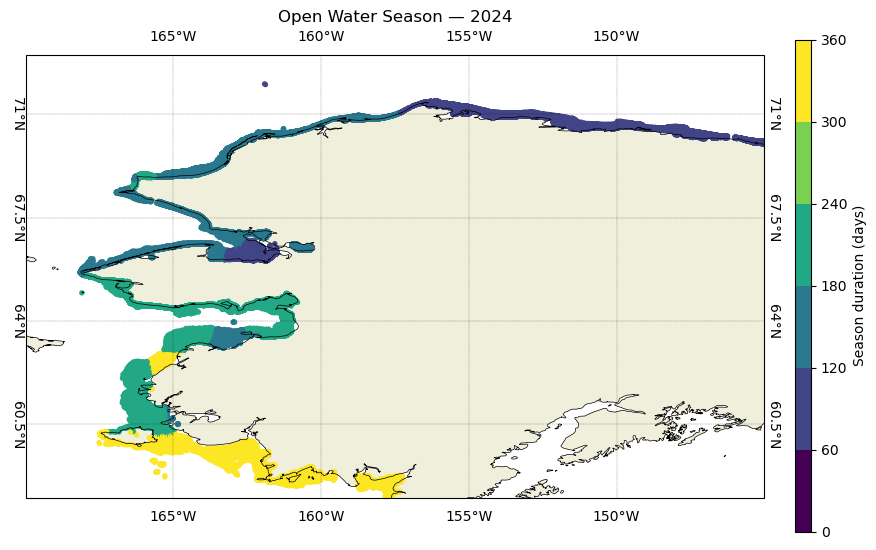

In [7]:
year_to_plot = 2024

lon1, lon2 = -170, -145
lat1, lat2 = 58, 73

sub = df_season.loc[df_season["year"] == year_to_plot, ["node","duration_days","lat","lon"]]

if not sub.empty:
    sub = (
        sub.dropna(subset=["duration_days"])
           .sort_values("node")
           .drop_duplicates("node", keep="last")
    )

xx, yy, zz = sub["lon"].values, sub["lat"].values, sub["duration_days"].values

# --- define bins and norm (set min/max here, not in scatter) ---
#bins = [0, 30, 60, 90, 120, 150, 180]  # example bins
bins = np.arange(0,365,60)
cmap    = plt.get_cmap('viridis', len(bins)-1)
norm = BoundaryNorm(bins, len(bins)-1)# ncolors=cmap, clip=False)

# --- plot ---
crs_data = ccrs.PlateCarree()
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=crs_data)

ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

gl = ax.gridlines(xlocs=np.arange(-190, -100, 5),
                  ylocs=np.arange(-90, 90, 3.5),
                  draw_labels=True, linewidth=0.3, color="black", alpha=0.5,
                  y_inline=False, linestyle="--", zorder=20)
gl.xlabels_top = False
gl.xlabels_bottom = True
gl.xlabel_style = {'rotation': 0}
gl.ylabels_left = False
gl.ylabels_right = True
gl.ylabel_style = {'rotation': -90}
gl.ypadding = 1.25
gl.xformatter = cart.mpl.gridliner.LONGITUDE_FORMATTER
gl.xpadding = 8
sc = ax.scatter(xx, yy, c=zz, s=8, cmap=cmap, norm=norm,
                transform=crs_data)

#cb = plt.colorbar(sc, ax=ax, shrink=0.8, pad=0.02, boundaries=bins, spacing="proportional")

cax = fig.add_axes([1., 0.075, 0.02, 0.82])
cb  = fig.colorbar(
    mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=cax, orientation='vertical',
    boundaries=bins, ticks=bins)
cb.set_label("Season duration (days)")
ax.set_title(f"Open Water Season — {year_to_plot}")
plt.tight_layout()
plt.savefig(f"/scratch/tmiesse/project/satellite/figures/hs_season_duration_{year_to_plot}.png", dpi=300)
plt.show()

In [22]:
from scipy.stats import linregress
records = []

# loop through each node
for node, group in df_season.groupby("node"):
    # drop NaN durations
    g = group.dropna(subset=["duration_days"]).sort_values("year")
    if len(g) < 5:  # require minimum years
        continue
    
    x = g["year"].values
    y = g["duration_days"].values
    
    # linear regression
    slope, intercept, r, p, stderr = linregress(x, y)
    
    records.append({
        "node": node,
        "lat": g["lat"].iloc[0],
        "lon": g["lon"].iloc[0],
        "trend_days_per_year": slope,
        "p_value": p,
        "r_value": r,
        "n_years": len(g)
    })

# tidy DataFrame of trends
df_trend = pd.DataFrame.from_records(records)
print(df_trend.head())

    node        lat         lon  trend_days_per_year  p_value   r_value  \
0  37846  59.932671 -162.350036            -1.050329  0.18381 -0.201766   
1  37847  59.931136 -162.344683            -1.050329  0.18381 -0.201766   
2  38040  59.933176 -162.363921            -1.050329  0.18381 -0.201766   
3  38051  59.931959 -162.371596            -1.050329  0.18381 -0.201766   
4  38052  59.931182 -162.378675            -1.050329  0.18381 -0.201766   

   n_years  
0       45  
1       45  
2       45  
3       45  
4       45  


In [23]:
df_trend.to_csv("hs_season_duration_trends.csv", index=False)

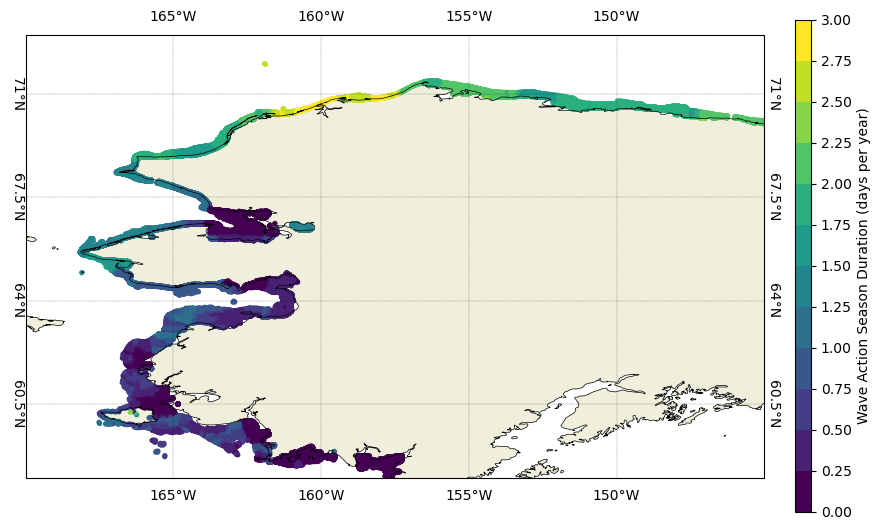

In [9]:


lon1, lon2 = -170, -145
lat1, lat2 = 58, 73



xx, yy, zz = df_trend["lon"].values, df_trend["lat"].values, df_trend["trend_days_per_year"].values

# --- define bins and norm (set min/max here, not in scatter) ---
#bins = [0, 30, 60, 90, 120, 150, 180]  # example bins
bins = np.arange(0,3.1,0.25)
cmap    = plt.get_cmap('viridis', len(bins)-1)
norm = BoundaryNorm(bins, len(bins)-1)# ncolors=cmap, clip=False)

crs_data = ccrs.PlateCarree()
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=crs_data)

ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

gl = ax.gridlines(xlocs=np.arange(-190, -100, 5),
                  ylocs=np.arange(-90, 90, 3.5),
                  draw_labels=True, linewidth=0.3, color="black", alpha=0.5,
                  y_inline=False, linestyle="--", zorder=20)
gl.xlabels_top = False
gl.xlabels_bottom = True
gl.xlabel_style = {'rotation': 0}
gl.ylabels_left = False
gl.ylabels_right = True
gl.ylabel_style = {'rotation': -90}
gl.ypadding = 1.25
gl.xformatter = cart.mpl.gridliner.LONGITUDE_FORMATTER
gl.xpadding = 8
sc = ax.scatter(xx, yy, c=zz, s=8, cmap=cmap, norm=norm,
                transform=crs_data)

#cb = plt.colorbar(sc, ax=ax, shrink=0.8, pad=0.02, boundaries=bins, spacing="proportional")

cax = fig.add_axes([1., 0.075, 0.02, 0.82])
cb  = fig.colorbar(
    mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=cax, orientation='vertical',
    boundaries=bins, ticks=bins)
cb.set_label("Wave Action Season Duration (days per year)")
#ax.set_title(f"Open Water Season — {year_to_plot}")
plt.tight_layout()
plt.savefig(f"/scratch/tmiesse/project/satellite/figures/hs_trends.png", dpi=300)
plt.show()

In [253]:
df_trend.to_csv('/scratch/tmiesse/project/satellite/hs_season_trend.csv')

In [24]:
df_season["onset_doy"] = pd.to_datetime(df_season["onset_date"]).dt.dayofyear

records = []

for node, g in df_season.groupby("node"):
    g = g.dropna(subset=["onset_doy"])
    if len(g) < 5:  # skip if not enough years
        continue
    
    x = g["year"].values
    y = g["onset_doy"].values
    
    slope, intercept = np.polyfit(x, y, 1)  # slope = days change per year
    records.append({
        "node": node,
        "trend_onset_days_per_year": slope,
        "n_years": len(x),
        "lat": g["lat"].iloc[0],
        "lon": g["lon"].iloc[0]
    })

df_onset_trend = pd.DataFrame.from_records(records)

In [25]:
df_onset_trend.to_csv("hs_season_onset_trends.csv", index=False)

In [26]:
from scipy.stats import linregress
# 1) ensure end_doy
if "end_doy" not in df_season.columns or df_season["end_doy"].isna().all():
    if not np.issubdtype(df_season["end_date"].dtype, np.datetime64):
        df_season["end_date"] = pd.to_datetime(df_season["end_date"], errors="coerce")
    df_season["end_doy"] = df_season["end_date"].dt.dayofyear

# 2) compute trends
recs = []
for node, g in df_season.groupby("node"):
    g = g.sort_values("year")
    y = g["end_doy"].to_numpy(dtype=float)
    x = g["year"].to_numpy(dtype=float)
    m = np.isfinite(y) & np.isfinite(x)
    if m.sum() < 5:
        continue
    slope, intercept, r, p, se = linregress(x[m], y[m])
    recs.append({
        "node": int(node),
        "lat": float(g["lat"].iloc[0]),
        "lon": float(g["lon"].iloc[0]),
        "trend_days_per_year": float(slope),
        "p_value": float(p),
        "r_value": float(r),
        "n_years": int(m.sum()),
    })

df_end_trend = pd.DataFrame.from_records(recs).sort_values("node").reset_index(drop=True)

# 3) save
out_csv = "hs_end_trend.csv"
df_end_trend.to_csv(out_csv, index=False)

print(df_end_trend.head())
print(f"Saved: {out_csv}")

    node        lat         lon  trend_days_per_year   p_value   r_value  \
0  37846  59.932671 -162.350036            -0.609881  0.037056 -0.311813   
1  37847  59.931136 -162.344683            -0.609881  0.037056 -0.311813   
2  38040  59.933176 -162.363921            -0.609881  0.037056 -0.311813   
3  38051  59.931959 -162.371596            -0.609881  0.037056 -0.311813   
4  38052  59.931182 -162.378675            -0.609881  0.037056 -0.311813   

   n_years  
0       45  
1       45  
2       45  
3       45  
4       45  
Saved: hs_end_trend.csv


In [26]:
df_end_trend.to_csv('/scratch/tmiesse/project/satellite/hs_season_end_trend.csv')

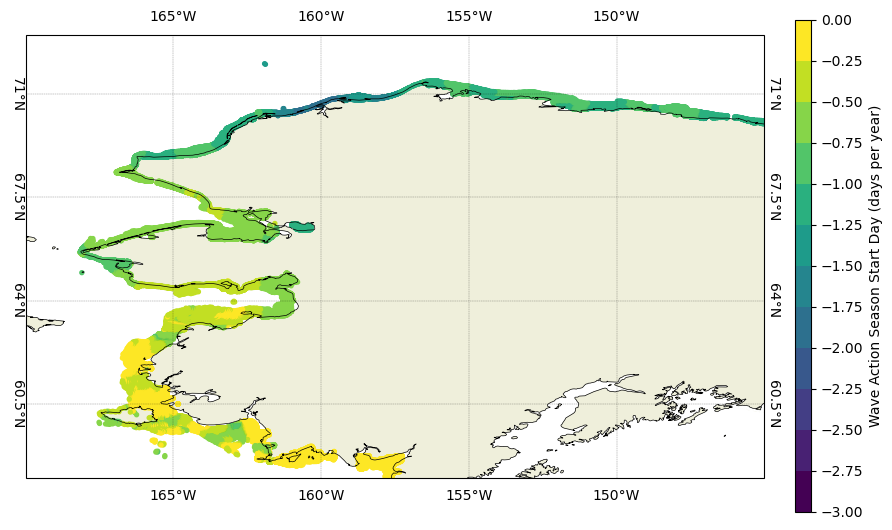

In [11]:


lon1, lon2 = -170, -145
lat1, lat2 = 58, 73



xx, yy, zz = df_onset_trend["lon"].values, df_onset_trend["lat"].values, df_onset_trend["trend_onset_days_per_year"].values

# --- define bins and norm (set min/max here, not in scatter) ---
#bins = [0, 30, 60, 90, 120, 150, 180]  # example bins
bins = np.arange(-3.,0.1,0.25)
cmap    = plt.get_cmap('viridis', len(bins)-1)
norm = BoundaryNorm(bins, len(bins)-1)# ncolors=cmap, clip=False)

crs_data = ccrs.PlateCarree()
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=crs_data)

ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

gl = ax.gridlines(xlocs=np.arange(-190, -100, 5),
                  ylocs=np.arange(-90, 90, 3.5),
                  draw_labels=True, linewidth=0.3, color="black", alpha=0.5,
                  y_inline=False, linestyle="--", zorder=20)
gl.xlabels_top = False
gl.xlabels_bottom = True
gl.xlabel_style = {'rotation': 0}
gl.ylabels_left = False
gl.ylabels_right = True
gl.ylabel_style = {'rotation': -90}
gl.ypadding = 1.25
gl.xformatter = cart.mpl.gridliner.LONGITUDE_FORMATTER
gl.xpadding = 8
sc = ax.scatter(xx, yy, c=zz, s=8, cmap=cmap, norm=norm,
                transform=crs_data)

#cb = plt.colorbar(sc, ax=ax, shrink=0.8, pad=0.02, boundaries=bins, spacing="proportional")

cax = fig.add_axes([1., 0.075, 0.02, 0.82])
cb  = fig.colorbar(
    mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=cax, orientation='vertical',
    boundaries=bins, ticks=bins)
cb.set_label("Wave Action Season Start Day (days per year)")
#ax.set_title(f"Open Water Season — {year_to_plot}")
plt.tight_layout()
plt.savefig(f"/scratch/tmiesse/project/satellite/figures/hs_start_trends.png", dpi=300)
plt.show()

In [15]:
df_onset_trend.to_csv('/scratch/tmiesse/project/satellite/hs_onset_trend.csv')

In [6]:
from shapely.geometry import Point
import pymannkendall as mk
import geopandas as gpd

# --- load & basic filtering (unchanged thresholds you provided) ---
seas = gpd.read_file("/scratch/tmiesse/project/world_seas/world_seas.shp")
df_season = pd.read_csv("hs_seasonal_daily.csv", parse_dates=["onset_date","end_date"])

# onset as day-of-year for trend
df_season["onset_doy"] = pd.to_datetime(df_season["onset_date"]).dt.dayofyear

summary = df_season.groupby("node")["duration_days"].agg(["min","max"])
cond_all_year = summary["min"] >= 280      # your current setting
MIN_VALID_DUR = 2
cond_too_short = summary["min"] <= MIN_VALID_DUR
bad_nodes = summary[cond_all_year | cond_too_short].index.tolist()

print(f"Removing {len(bad_nodes)} nodes "
      f"({int(cond_all_year.sum())} always year-round, "
      f"{int(cond_too_short.sum())} never >{MIN_VALID_DUR} days)")
df_season = df_season[~df_season["node"].isin(bad_nodes)].copy()
df_season["duration_days"] = pd.to_numeric(df_season["duration_days"], errors="coerce")

# keep only 1980 and 2024
sub = df_season[df_season["year"].isin([1980, 2024])][["node", "year", "duration_days", "lat", "lon"]]

# pivot so each node has both years' durations
pivot = sub.pivot_table(index=["node", "lat", "lon"], columns="year", values="duration_days", aggfunc="median")

# compute difference (2024 - 1980)
pivot["duration_diff"] = pivot[2024] - pivot[1980]
pivot['duration_diff'].loc[pivot['duration_diff']<0] = np.nan
diff_raw = pivot[2024] - pivot[1980]
bad_mask = diff_raw < 0
bad_nodes = pd.Index(pivot.index.get_level_values("node")[bad_mask]).unique().tolist()

# optional: inspect/save removed nodes
# pd.Series(bad_nodes, name="node").to_csv("nodes_removed_negative_duration_diff.csv", index=False)

# remove from df_season
df_season = df_season[~df_season["node"].isin(bad_nodes)].copy()

Removing 41798 nodes (11823 always year-round, 29975 never >2 days)


In [7]:
name_col = None
for c in seas.columns:
    if str(c).lower() in ("name","name_en","sea_name","seas","sea"):
        name_col = c; break
target_names = {"Beaufort Sea","North Bering Sea","Chukchi Sea"}
seas3 = seas[seas[name_col].isin(target_names)].to_crs(4326)

unique_nodes = df_season[["node","lat","lon"]].drop_duplicates().reset_index(drop=True)
g_nodes = gpd.GeoDataFrame(
    unique_nodes,
    geometry=[Point(lon, lat) for lon, lat in zip(unique_nodes["lon"], unique_nodes["lat"])],
    crs="EPSG:4326"
)
joined = gpd.sjoin(g_nodes, seas3[[name_col,"geometry"]], predicate="within", how="inner")
node_to_sea = joined.set_index("node")[name_col].to_dict()
df_season["sea"] = df_season["node"].map(node_to_sea)

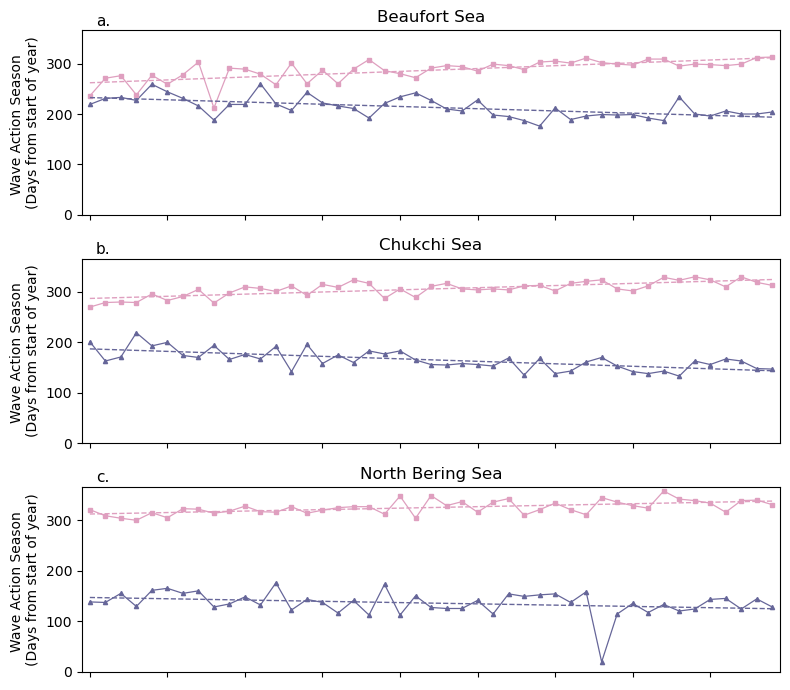

In [8]:
if "end_doy" not in df_season.columns or df_season["end_doy"].isna().all():
    df_season["end_doy"] = pd.to_datetime(df_season["end_date"]).dt.dayofyear
colors = ['#bfbfbf']
seas_order  = ["Beaufort Sea", "Chukchi Sea", "North Bering Sea"]
subplot_labels = ["a.", "b.", "c."]
fig, axes = plt.subplots(len(seas_order), 1, figsize=(8, 7), sharex=True)
plt.subplots_adjust(right=0.85, hspace=0.4)

for i, sea_name in enumerate(seas_order):
    ax = axes[i]
    sub = df_season.loc[df_season["sea"] == sea_name].copy()
    if sub.empty:
        continue

    # duration (days)
    d_mean = sub.groupby("year")["duration_days"].mean()
    d_med  = sub.groupby("year")["duration_days"].median()

    # onset (DoY)
    o_mean = sub.groupby("year")["onset_doy"].mean()
    o_med  = sub.groupby("year")["onset_doy"].median()

    # end (DoY)
    e_mean = sub.groupby("year")["end_doy"].mean()
    e_med  = sub.groupby("year")["end_doy"].median()

    years_min = int(sub["year"].min())
    years_max = int(sub["year"].max())
    xr = np.arange(years_min, years_max + 1)
    '''
    # duration trends
    dur_trend_labels = []
    if len(d_med) >= 2:
        x_m, y_m = d_med.index.values, d_med.values
        ms, bi   = np.polyfit(x_m, y_m, 1)
        mk_med   = mk.original_test(y_m) if len(y_m) >= 3 else None
        dur_trend_labels.append(("median_dur", ms, bi, mk_med))
    if len(d_mean) >= 2:
        x_a, y_a = d_mean.index.values, d_mean.values
        ss, bi2  = np.polyfit(x_a, y_a, 1)
        mk_mean  = mk.original_test(y_a) if len(y_a) >= 3 else None
        dur_trend_labels.append(("mean_dur", ss, bi2, mk_mean))
    '''
    # onset trends
    onset_trend_labels = []
    #if len(o_med) >= 2:
    x_om, y_om = o_med.index.values, o_med.values
    oms, obi   = np.polyfit(x_om, y_om, 1)
    mk_omed    = mk.original_test(y_om) if len(y_om) >= 3 else None
    onset_trend_labels.append(("median_onset", oms, obi, mk_omed))
    '''
    #if len(o_mean) >= 2:
    x_oa, y_oa = o_mean.index.values, o_mean.values
    oss, obi2  = np.polyfit(x_oa, y_oa, 1)
    mk_omean   = mk.original_test(y_oa) if len(y_oa) >= 3 else None
    onset_trend_labels.append(("mean_onset", oss, obi2, mk_omean))
    '''
    # end trends
    end_trend_labels = []
    if len(e_med) >= 2:
        x_em, y_em = e_med.index.values, e_med.values
        ens, ebi   = np.polyfit(x_em, y_em, 1)
        mk_emed    = mk.original_test(y_em) if len(y_em) >= 3 else None
        end_trend_labels.append(("median_end", ens, ebi, mk_emed))
    '''
    if len(e_mean) >= 2:
        x_ea, y_ea = e_mean.index.values, e_mean.values
        ess, ebi2  = np.polyfit(x_ea, y_ea, 1)
        mk_emean   = mk.original_test(y_ea) if len(y_ea) >= 3 else None
        end_trend_labels.append(("mean_end", ess, ebi2, mk_emean))
    '''

    # figure
    #fig, ax = plt.subplots(figsize=(9, 4))
    #ax2 = ax.twinx()
    # duration series
    #l1, = ax2.plot(d_mean.index, d_mean.values, "-o", color="#bfbfbf",
    #              linewidth=0.8, markersize=2.5, label="Mean duration", zorder=2)
    #l2, = ax2.plot(d_med.index,  d_med.values,  "-o", color="#8c8c8c",
    #              linewidth=0.8, markersize=2.5, label="Median duration", zorder=2)
    #ax.bar(d_med.index.values, d_med.values, color=colors, alpha=0.65, width=0.8)#, label=f"{sea_name}"
    '''
    # duration trends
    handles = [l1, l2]
    for tag, slope, intercept, mkres in dur_trend_labels:
        lbl = ("Mean" if tag == "mean_dur" else "Median") + f" trend: {slope:.2f} "+r"$[\frac{days}{yr}]$"
        if mkres: lbl += f"\n (p={mkres.p:.2f} τ={mkres.Tau:.2f})"
        color = "#bfbfbf" if tag == "mean_dur" else "#8c8c8c"
        ls, = ax2.plot(xr, slope*xr + intercept, linestyle="--", color=color, linewidth=1., label=lbl, zorder=3)
        handles.append(ls)
    '''
    # onset series
    #l3, = ax.plot(o_mean.index, o_mean.values, "-^", linewidth=0.9, color="#00b300",
    #              markersize=3, label="Mean onset", zorder=2)
    l4, = ax.plot(o_med.index,  o_med.values,  "-^", linewidth=0.9, color="#666699",
                  markersize=3, label="Median onset", zorder=2)

    # onset trends
    handles2 = []
    for tag, slope, intercept, mkres in onset_trend_labels:
        lbl = ("Mean onset" if tag == "mean_onset" else "Median onset") + f" trend: {slope:.2f} "+r"$[\frac{days}{yr}]$"
        if mkres: lbl += f"\n (p={mkres.p:.2f} τ={mkres.Tau:.2f})"
        color = "#00b300" if tag == "mean_onset" else "#666699"
        start_line = slope*xr + intercept
        ls2, = ax.plot(xr, start_line, color=color, linewidth=1., linestyle="--", label='WAS onset', zorder=3)
        handles2.append(ls2)

    # end series
    #l5, = ax.plot(e_mean.index, e_mean.values, "-s", linewidth=0.9, color="#6699ff",
    #              markersize=3, label="Mean end", zorder=2)
    l6, = ax.plot(e_med.index,  e_med.values,  "-s", linewidth=0.9, color="#df9fbf",
                  markersize=3, label="Median end", zorder=2)
    
    # end trends
    handles3 = []
    for tag, slope, intercept, mkres in end_trend_labels:
        lbl = ("Mean end" if tag == "mean_end" else "Median end") + f" trend: {slope:.2f} "+r"$[\frac{days}{yr}]$"
        if mkres: lbl += f"\n (p={mkres.p:.2f} τ={mkres.Tau:.2f})"
        color = "#6699ff" if tag == "mean_end" else "#df9fbf"
        end_line = slope*xr + intercept
        ls3, = ax.plot(xr,end_line , color=color, linewidth=1., linestyle="--", label='WAS end', zorder=3)
        handles3.append(ls3)

    #ax.fill_between(o_mean.index, start_line, end_line,color='gray', alpha=0.2, label='Mean Season Range', zorder=1)
    # axes/legend
    ylabel = "Wave Action Season \n"\
            "(Days from start of year)"
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 366)
    #ax2.set_ylim(0, 366)
    #ax2.set_ylabel("Wave Action Season Duration (days)",color='#808080')
    #ax2.tick_params(colors='#808080')
    ax.set_xticklabels(['','','','','','','','',''])
    ax.set_xlim(1979.5, 2024.5)
    ax.set_title(f"{sea_name}")
    ax.text(0.02, 1.09, subplot_labels[i], transform=ax.transAxes,
            fontsize=11, fontweight=None, va="top", ha="left")
    all_handles =  handles2 + handles3#handles +
#ax.legend(all_handles, [h.get_label() for h in all_handles],
#            loc="upper left", fontsize=9, frameon=False, ncol=3, bbox_to_anchor=(0.25, -0.15))

plt.tight_layout()
plt.savefig(f"/scratch/tmiesse/project/satellite/figures/hs_season_duration_nolegend.png", dpi=720)
plt.show()

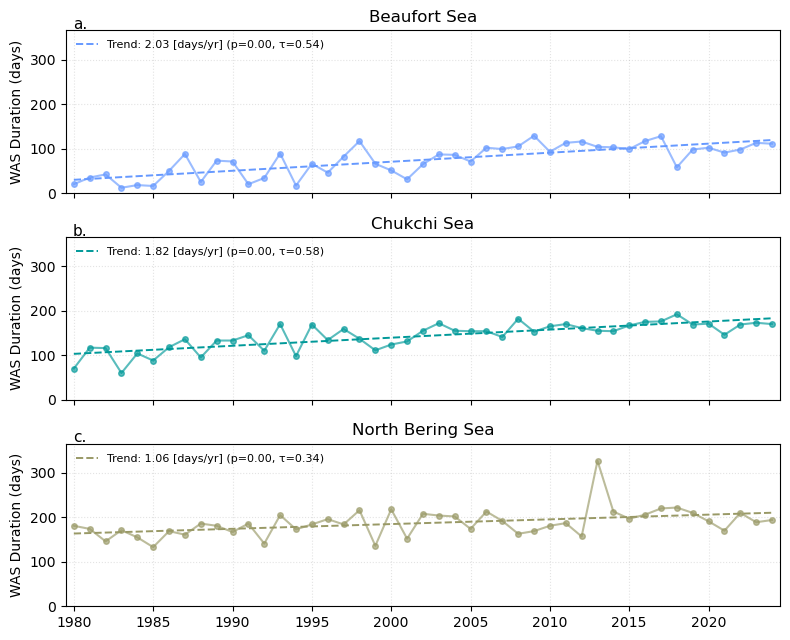

In [28]:

# ensure end_doy exists if needed
if "end_doy" not in df_season.columns or df_season["end_doy"].isna().all():
    df_season["end_doy"] = pd.to_datetime(df_season["end_date"]).dt.dayofyear

seas_order = ["Beaufort Sea", "Chukchi Sea", "North Bering Sea"]
subplot_labels = ["a.", "b.", "c."]
colors = ['#6699ff', '#009999', '#999966']

fig, axes = plt.subplots(len(seas_order), 1, figsize=(8, 6.5), sharex=True)
plt.subplots_adjust(right=0.85, hspace=0.4)

for i, sea_name in enumerate(seas_order):
    ax = axes[i]
    sub = df_season.loc[df_season["sea"] == sea_name].copy()
    if sub.empty:
        ax.set_title(f"{sea_name} (no data)")
        ax.set_yticks([])
        continue

    # yearly median duration
    d_med = sub.groupby("year")["duration_days"].median().dropna()
    years_min = int(d_med.index.min())
    years_max = int(d_med.index.max())
    xr = np.arange(years_min, years_max + 1)

    # histogram over years (bar chart of median duration per year)
    ax.plot(d_med.index.values, d_med.values,'-o', color=colors[i], alpha=0.65,markersize=4)#, width=0.8)#, label=f"{sea_name}"

    # trend on median duration
    #if len(d_med) >= 2:
    x_m = d_med.index.values
    y_m = d_med.values
    slope, intercept = np.polyfit(x_m, y_m, 1)
    mkres = mk.original_test(y_m) if len(y_m) >= 3 else None
    ax.plot(xr, slope * xr + intercept, linestyle="--", color=colors[i], linewidth=1.4,
            label=f"Trend: {slope:.2f} [days/yr]{'' if mkres is None else f' (p={mkres.p:.2f}, τ={mkres.Tau:.2f})'}")

    # axes styling
    ax.set_ylabel("WAS Duration (days)",fontsize=10)
    ax.set_ylim(0, 366)
    ax.set_xlim(1979.5, 2024.5)
    ax.set_title(f"{sea_name}", fontsize=12)
    ax.grid(True, linestyle=":", alpha=0.35)
    ax.text(0.01, 1.08, subplot_labels[i], transform=ax.transAxes, fontsize=11, va="top", ha="left")
    ax.legend(loc="upper left", fontsize=8, frameon=False)

#ax.legend(all_handles, [h.get_label() for h in all_handles],
#            loc="upper left", fontsize=9, frameon=False, ncol=3, bbox_to_anchor=(0.25, -0.15))
plt.tight_layout()
plt.savefig("/scratch/tmiesse/project/satellite/figures/hs_season_duration_hist.png", dpi=720)
plt.show()

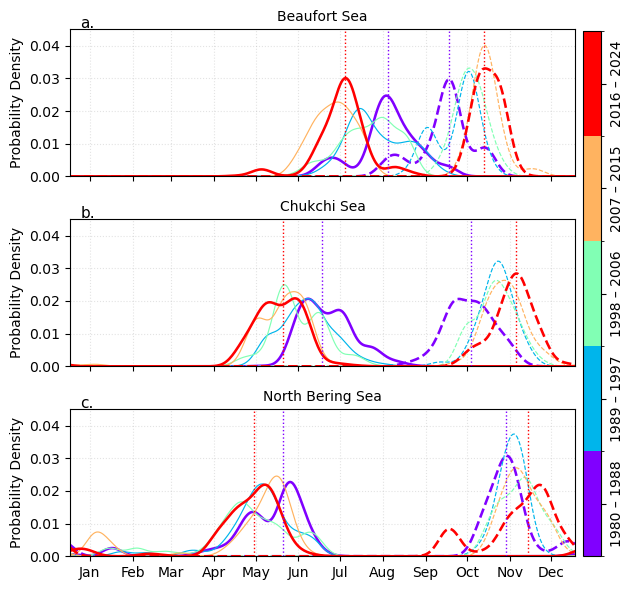

In [14]:
from matplotlib.cm import get_cmap
from matplotlib.colors import ListedColormap, BoundaryNorm

if "onset_doy" not in df_season.columns or df_season["onset_doy"].isna().all():
    df_season["onset_doy"] = pd.to_datetime(df_season["onset_date"]).dt.dayofyear
if "end_doy" not in df_season.columns or df_season["end_doy"].isna().all():
    df_season["end_doy"] = pd.to_datetime(df_season["end_date"]).dt.dayofyear

# Mask first 30 days (Jan 1–30)
#df_season.loc[df_season["onset_doy"] <= 30, "onset_doy"] = np.nan
#df_season.loc[df_season["end_doy"] <= 30, "end_doy"] = np.nan

def _pdf_circular_smooth(days, bandwidth_days=18):
    vals = np.asarray(days, dtype=float)
    vals = vals[np.isfinite(vals)]
    vals = vals[(vals >= 1) & (vals <= 366)]
    x = np.arange(1, 367)
    if vals.size == 0:
        return x, np.zeros_like(x, dtype=float)

    counts, _ = np.histogram(vals, bins=np.arange(1, 368))
    counts = counts.astype(float)

    sigma = max(1.0, float(bandwidth_days))
    k_half = int(np.ceil(4 * sigma))
    kx = np.arange(-k_half, k_half + 1, dtype=float)
    kern = np.exp(-(kx**2) / (2 * sigma**2)); kern /= kern.sum()

    pad = k_half
    circ = np.r_[counts[-pad:], counts, counts[:pad]]
    smoothed = np.convolve(circ, kern, mode="same")[pad:-pad]
    #smoothed[:30] = 0.0

    area = smoothed.sum()
    if area > 0:
        smoothed = smoothed / area
    return x, smoothed

ymin = int(df_season["year"].min())
ymax = int(df_season["year"].max())
edges = np.arange(1980, 2026, 9)
labels = [f"{a} – {b-1}" for a, b in zip(edges[:-1], edges[1:])]

def year_bin10(y):
    idx = np.searchsorted(edges, y, side="right") - 1
    return labels[max(0, min(idx, len(labels)-1))]

df_season["_bin1"] = df_season["year"].apply(year_bin10)
bins_unique = [lab for lab in labels if lab in df_season["_bin1"].unique()]

# Discrete colormap
base_cmap = get_cmap("rainbow")
colors_list = [base_cmap(i / max(1, len(bins_unique)-1)) for i in range(len(bins_unique))]
disc_cmap = ListedColormap(colors_list)
K = len(bins_unique)
boundaries = np.arange(-0.5, K + 0.5, 1.0)
norm = BoundaryNorm(boundaries, disc_cmap.N)
bin_index = {lab: i for i, lab in enumerate(bins_unique)}

# Plot setup
seas_order  = ["Beaufort Sea", "Chukchi Sea", "North Bering Sea"]
subplot_labels = ["a.", "b.", "c."]
month_ticks = [15, 46, 74, 105, 135, 166, 196, 227, 258, 288, 319, 349]
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, axes = plt.subplots(len(seas_order), 1, figsize=(7, 6), sharex=True)
plt.subplots_adjust(right=0.85, hspace=0.4)

for i, sea_name in enumerate(seas_order):
    ax = axes[i]
    sub_sea = df_season.loc[df_season["sea"] == sea_name]


    if sub_sea.empty:
        continue

    for lab in bins_unique:
        sub = sub_sea.loc[sub_sea["_bin1"] == lab]
        onset_vals = sub["onset_doy"].dropna().astype(int).values
        end_vals   = sub["end_doy"].dropna().astype(int).values
        x, y_on = _pdf_circular_smooth(onset_vals, bandwidth_days=7)
        _, y_en = _pdf_circular_smooth(end_vals,   bandwidth_days=7)
        if ('1980' in lab):
            onset_old = sub["onset_doy"].dropna().median()
            end_old   = sub["end_doy"].dropna().median()
            c_old = colors_list[bin_index[lab]]
        if ('2024' in lab):
            onset_new = sub["onset_doy"].dropna().median()
            end_new   = sub["end_doy"].dropna().median()
            c_new = colors_list[bin_index[lab]]
        color = colors_list[bin_index[lab]]

        lw = 1.85 if (lab == bins_unique[0] or lab == bins_unique[-1]) else 0.85

        if np.any(np.isfinite(y_on)):
            ax.plot(x, y_on, color=color, lw=lw)
        if np.any(np.isfinite(y_en)):
            ax.plot(x, y_en, color=color, lw=lw, ls="--")
    ax.plot([onset_old, onset_old], [0, 0.045], color=c_old, lw=1.0, ls=":")
    ax.plot([end_old, end_old], [0, 0.045], color=c_old, lw=1.0, ls=":")
    ax.plot([onset_new, onset_new], [0, 0.045], color=c_new, lw=1.0, ls=":")
    ax.plot([end_new, end_new], [0, 0.045], color=c_new, lw=1.0, ls=":")
    ax.set_xlim(1, 366)
    ax.set_xticks(month_ticks)
    ax.set_xticklabels(month_labels)
    ax.set_ylim(0, 0.045)
    #ax.set_yticks([])
    ax.set_ylabel("Probability Density", fontsize=10)
    ax.set_title(f"{sea_name}", fontsize=10)
    ax.grid(True, linestyle=":", alpha=0.35)

    # Add subplot label (a, b, c)
    ax.text(0.02, 1.09, subplot_labels[i], transform=ax.transAxes,
            fontsize=11, fontweight=None, va="top", ha="left")

# Shared colorbar
sm = plt.cm.ScalarMappable(cmap=disc_cmap, norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.84, 0.065, 0.025, 0.875])
cbar = plt.colorbar(sm, cax=cbar_ax, orientation="vertical", ticks=np.arange(K))
cbar.ax.set_yticklabels(bins_unique,rotation=90,va="center")


plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig("/scratch/tmiesse/project/satellite/figures/onset_end_pdf_9yr_discrete_subplot_labeled.png", dpi=720)
plt.show()

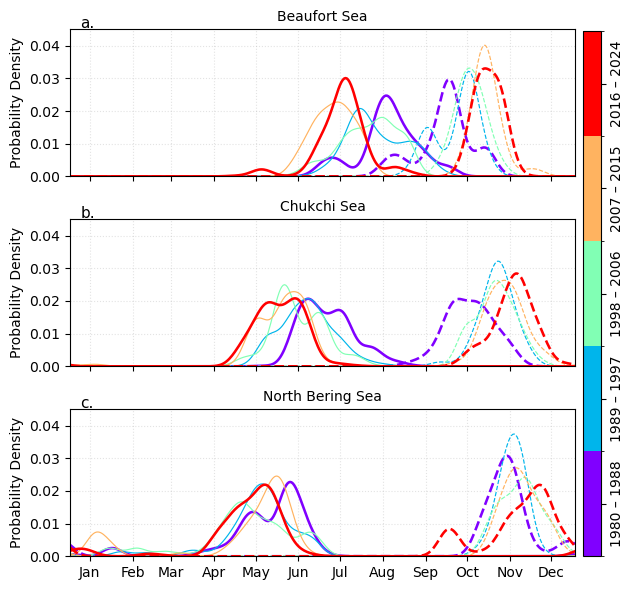

In [13]:
from matplotlib.cm import get_cmap
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np
import matplotlib.pyplot as plt

if "onset_doy" not in df_season.columns or df_season["onset_doy"].isna().all():
    df_season["onset_doy"] = pd.to_datetime(df_season["onset_date"]).dt.dayofyear
if "end_doy" not in df_season.columns or df_season["end_doy"].isna().all():
    df_season["end_doy"] = pd.to_datetime(df_season["end_date"]).dt.dayofyear

def _pdf_circular_smooth(days, bandwidth_days=18):
    vals = np.asarray(days, dtype=float)
    vals = vals[np.isfinite(vals)]
    vals = vals[(vals >= 1) & (vals <= 366)]
    x = np.arange(1, 367, dtype=int)
    if vals.size == 0:
        return x, np.zeros_like(x, dtype=float)

    # histogram with unit bin width (DOY bins)
    counts, _ = np.histogram(vals, bins=np.arange(1, 368))
    counts = counts.astype(float)

    # normalize counts to a PMF first → sum == 1 exactly
    total = counts.sum()
    if total > 0:
        counts /= total

    # Gaussian kernel (sum=1) on circular domain → mass preserved
    sigma = max(1.0, float(bandwidth_days))
    k_half = int(np.ceil(4 * sigma))
    kx = np.arange(-k_half, k_half + 1, dtype=float)
    kern = np.exp(-(kx**2) / (2 * sigma**2))
    kern /= kern.sum()

    pad = k_half
    circ = np.r_[counts[-pad:], counts, counts[:pad]]
    smoothed = np.convolve(circ, kern, mode="same")[pad:-pad]

    # re-normalize defensively to enforce sum == 1
    area = smoothed.sum()
    if area > 0:
        smoothed = smoothed / area

    return x, smoothed

# year bins (as before)
edges = np.arange(1980, 2026, 9)
labels = [f"{a} – {b-1}" for a, b in zip(edges[:-1], edges[1:])]
def year_bin10(y):
    idx = np.searchsorted(edges, y, side="right") - 1
    return labels[max(0, min(idx, len(labels)-1))]
df_season["_bin1"] = df_season["year"].apply(year_bin10)
bins_unique = [lab for lab in labels if lab in df_season["_bin1"].unique()]

# colors
base_cmap = get_cmap("rainbow")
colors_list = [base_cmap(i / max(1, len(bins_unique)-1)) for i in range(len(bins_unique))]
disc_cmap = ListedColormap(colors_list)
K = len(bins_unique)
boundaries = np.arange(-0.5, K + 0.5, 1.0)
norm = BoundaryNorm(boundaries, disc_cmap.N)
bin_index = {lab: i for i, lab in enumerate(bins_unique)}

# plotting
seas_order  = ["Beaufort Sea", "Chukchi Sea", "North Bering Sea"]
subplot_labels = ["a.", "b.", "c."]
month_ticks = [15, 46, 74, 105, 135, 166, 196, 227, 258, 288, 319, 349]
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, axes = plt.subplots(len(seas_order), 1, figsize=(7, 6), sharex=True)
plt.subplots_adjust(right=0.85, hspace=0.4)

# optional: check integrals
CHECK_AREA = True

for i, sea_name in enumerate(seas_order):
    ax = axes[i]
    sub_sea = df_season.loc[df_season["sea"] == sea_name]
    if sub_sea.empty:
        continue

    for lab in bins_unique:
        sub = sub_sea.loc[sub_sea["_bin1"] == lab]
        onset_vals = sub["onset_doy"].to_numpy(dtype=float)
        end_vals   = sub["end_doy"].to_numpy(dtype=float)

        x, y_on = _pdf_circular_smooth(onset_vals, bandwidth_days=7)
        _, y_en = _pdf_circular_smooth(end_vals,   bandwidth_days=7)

        if CHECK_AREA:
            # unit bin width → sum should be 1 (within numerical tolerance)
            if not np.isclose(np.nansum(y_on), 1.0, atol=1e-6):
                print(f"[WARN] Onset area != 1 for {sea_name}, bin {lab}: {np.nansum(y_on):.6f}")
            if not np.isclose(np.nansum(y_en), 1.0, atol=1e-6):
                print(f"[WARN] End area != 1 for {sea_name}, bin {lab}: {np.nansum(y_en):.6f}")

        color = colors_list[bin_index[lab]]
        lw = 1.85 if (lab == bins_unique[0] or lab == bins_unique[-1]) else 0.85
        if np.any(np.isfinite(y_on)): ax.plot(x, y_on, color=color, lw=lw)
        if np.any(np.isfinite(y_en)): ax.plot(x, y_en, color=color, lw=lw, ls="--")

    ax.set_xlim(1, 366)
    ax.set_xticks(month_ticks)
    ax.set_xticklabels(month_labels)
    ax.set_ylim(0, 0.045)
    ax.set_ylabel("Probability Density", fontsize=10)
    ax.set_title(f"{sea_name}", fontsize=10)
    ax.grid(True, linestyle=":", alpha=0.35)
    ax.text(0.02, 1.09, subplot_labels[i], transform=ax.transAxes, fontsize=11, va="top", ha="left")

# shared colorbar
sm = plt.cm.ScalarMappable(cmap=disc_cmap, norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.84, 0.065, 0.025, 0.875])
cbar = plt.colorbar(sm, cax=cbar_ax, orientation="vertical", ticks=np.arange(K))
cbar.ax.set_yticklabels(bins_unique, rotation=90, va="center")

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig("/scratch/tmiesse/project/satellite/figures/onset_end_pdf_9yr_discrete_subplot_labeled.png", dpi=720)
plt.show()